In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from LinearRegression import LinearRegression

In [5]:
X, y = datasets.make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=4
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234
)

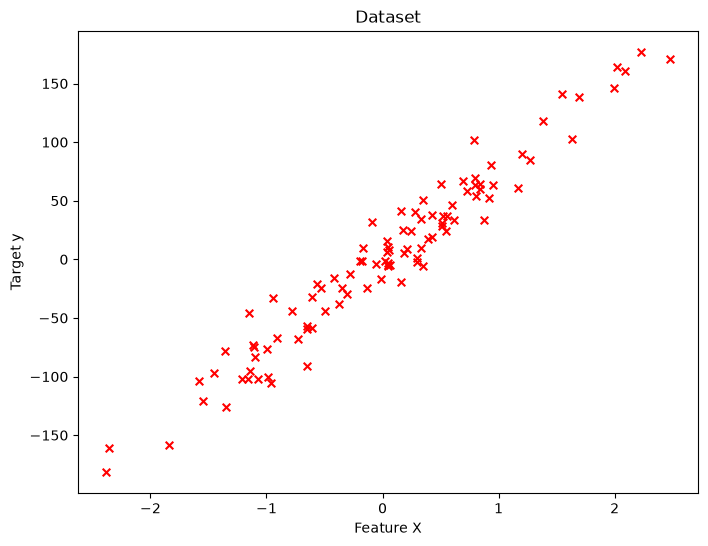

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    y,
    color="r",
    marker="x",
    s=30
)

plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Dataset")
plt.show()

In [11]:
reg = LinearRegression(lr=0.01, n_iters=1000)
reg.fit(X_train, y_train)

predictions = reg.predict(X_test)

def mse(y_test, predictions):
    return np.mean((y_test - predictions) ** 2)

print("MSE:", mse(y_test, predictions))
print("w:", reg.w)
print("b:", reg.b)
print("Final cost:", reg.J_history[-1])

MSE: 305.7719958301902
w: [75.05642756]
b: -0.14185705476881225
Final cost: 143.1915141121935


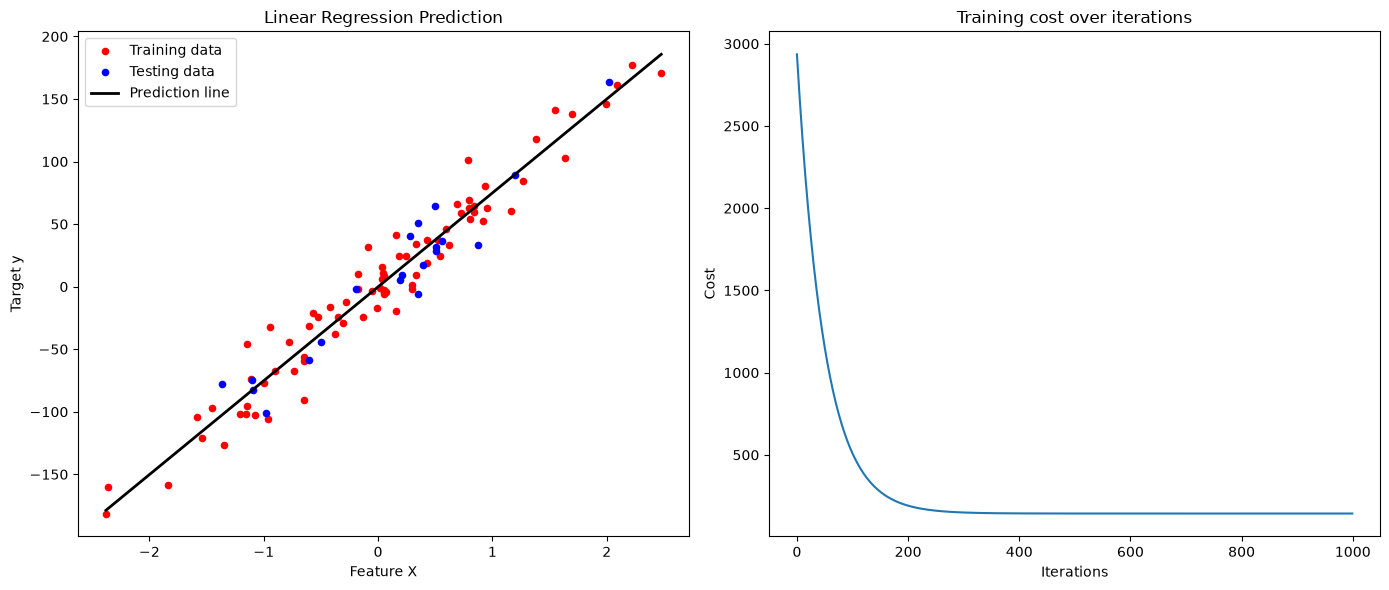

In [ ]:
f_wb_line = reg.predict(X)

sorted_indices = np.argsort(X[:, 0])
X_sorted = X[sorted_indices]
f_wb_line_sorted = f_wb_line[sorted_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left graph: Linear regression prediction
axes[0].scatter(
    X_train[:, 0],
    y_train,
    c="r",
    s=20,
    label="Training data"
)

axes[0].scatter(
    X_test[:, 0],
    y_test,
    c="b",
    s=20,
    label="Testing data"
)

axes[0].plot(
    X_sorted[:, 0],
    f_wb_line_sorted,
    color="black",
    linewidth=2,
    label="Prediction line"
)

axes[0].set_xlabel("Feature X")
axes[0].set_ylabel("Target y")
axes[0].set_title("Linear Regression Prediction")
axes[0].legend()

# Right graph: Training cost
axes[1].plot(reg.J_history)

axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Cost")
axes[1].set_title("Training cost over iterations")

plt.tight_layout()
plt.show()
